In [1]:
# 3. Tahap penggabungan ketiga dataset

import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 3.1. Memuat Ketiga Dataset
data_frame_beras_n = pd.read_csv('../data/raw/komoditas_beras_2022_2026.csv')
data_frame_cuaca_n = pd.read_csv('../data/raw/data_cuaca_2022_2026.csv')
data_frame_koordinat_n = pd.read_csv('../data/raw/koordinat_provinsi.csv')

# 3.2. Standarisasi Tipe Data Tanggal (Date_Param)
# Memastikan format tanggal sama persis agar bisa digabungkan
data_frame_beras_n['Date_Param'] = pd.to_datetime(data_frame_beras_n['Date_Param'])
data_frame_cuaca_n['Date_Param'] = pd.to_datetime(data_frame_cuaca_n['Date_Param'])

# 3.3. Penggabungan Data (Data Merging)
# Menggabungkan data harga beras dengan cuaca berdasarkan Tanggal dan Provinsi
df_merged = pd.merge(data_frame_beras_n, data_frame_cuaca_n, on=['Date_Param', 'Province_Name'], how='left')

# Menggabungkan hasil di atas dengan data koordinat berdasarkan Provinsi
df_final = pd.merge(df_merged, data_frame_koordinat_n, on=['Province_Name'], how='left')

# 3.4. Buang Kolom yang tidak diperlukan
kolom_penting = [
    'Date_Param', 'Province_Name', 'Latitude', 'Longitude', 
    'Temperature', 'Precipitation', 'Price'
]
df_final = df_final[kolom_penting]
df_final.rename(columns={'Date_Param': 'Date'}, inplace=True)

# Mengurutkan berdasarkan Provinsi dan Tanggal
df_final = df_final.sort_values(by=['Province_Name', 'Date']).reset_index(drop=True)

# 3.5. Menyimpan Dataset Akhir
df_final.to_csv('../data/processed/dataset_lengkap.csv', index=False)

print("\ndata cek")
display(df_final.head())

print("\ncek missing value:")
display(df_final.isnull().sum())


data cek


,Date,Province_Name,Latitude,Longitude,Temperature,Precipitation,Price
0,2022-01-01,Aceh,4.368549,97.025302,18.84,32.27,10250.0
1,2022-01-02,Aceh,4.368549,97.025302,19.11,8.00,10250.0
2,2022-01-03,Aceh,4.368549,97.025302,19.10,8.89,10250.0
3,2022-01-04,Aceh,4.368549,97.025302,19.81,19.47,10300.0
4,2022-01-05,Aceh,4.368549,97.025302,20.35,0.84,10350.0



cek missing value:


Date             0
Province_Name    0
Latitude         0
Longitude        0
Temperature      0
Precipitation    0
Price            0
dtype: int64

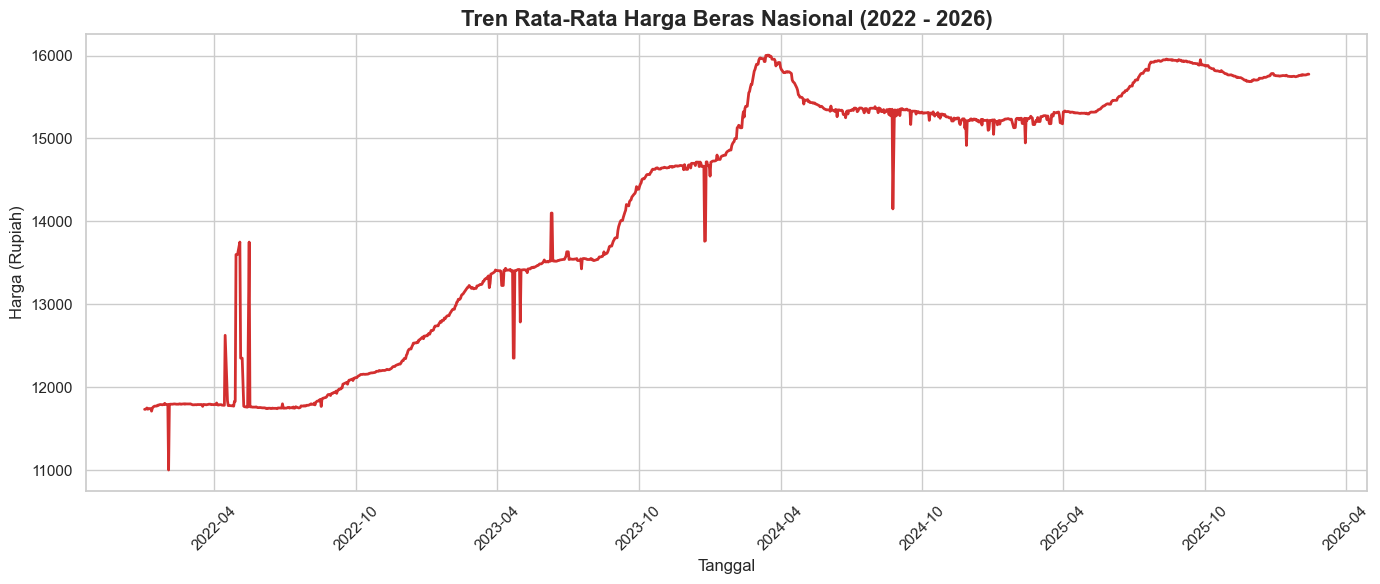

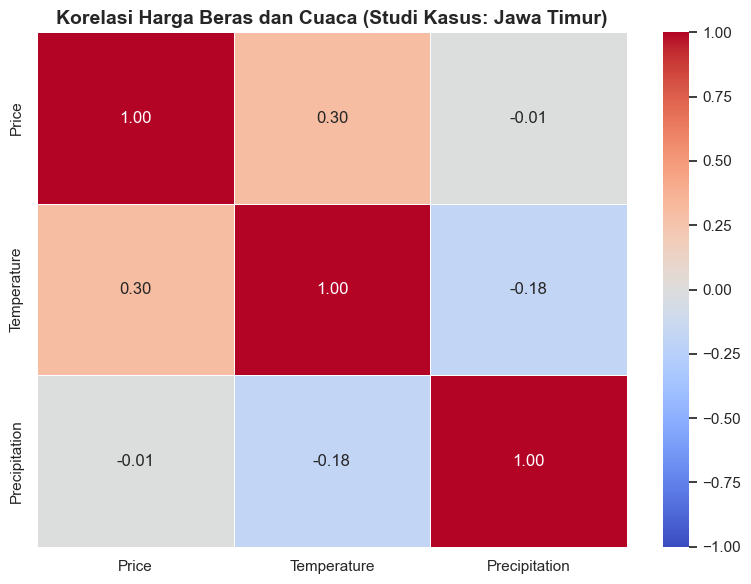

In [2]:
# 4. Menciptakan visual kondisi data yang ada

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

sns.set_theme(style="whitegrid")

# 4.1. GRAFIK TREN HARGA BERAS NASIONAL (2022-2026)
# Menghitung harga rata-rata secara menyeluruh atau nasional
df_national = df_final.groupby('Date')['Price'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_national, x='Date', y='Price', color='#d32f2f', linewidth=2)
plt.title('Tren Rata-Rata Harga Beras Nasional (2022 - 2026)', fontsize=16, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga (Rupiah)', fontsize=12)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('../laporan/tren_harga_beras_secara_nasional.png', dpi=300)
plt.show()


# 4.2. GRAFIK KORELASI
# Diambil sampel, "Jawa Timur"
df_jatim = df_final[df_final['Province_Name'] == 'Jawa Timur']

plt.figure(figsize=(8, 6))
# Menghitung korelasi antara Harga, Suhu, dan Curah Hujan
korelasi = df_jatim[['Price', 'Temperature', 'Precipitation']].corr()

# Membuat Heatmap
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title('Korelasi Harga Beras dan Cuaca (Studi Kasus: Jawa Timur)', fontsize=14, fontweight='bold')
plt.tight_layout()

# Simpan grafik ke folder reports
plt.savefig('../laporan/korelasi_cuaca_dengan_harga_jatim.png', dpi=300)
plt.show()